In [2]:
import joblib
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

from ml_baselines.modelling.train import train_mlp, train_mlp_grid_search
from ml_baselines.config import Config

In [3]:
cfg = Config()
site = "MHD"

Manually train an MLP model

In [5]:
params_dict = {'activation': 'relu', 'alpha': 0.0001, 'batch_size': 100, 'early_stopping': True, 'hidden_layer_sizes': (100,), 'learning_rate': 'constant', 'max_iter': 1000, 'solver': 'adam'}
model, x, y = train_mlp("MHD", balance=0.5, balance_method="deterministic",
                        **params_dict)

Training MLP model for site: MHD
Number of training points: 11030
... number of baseline points: 5515 (50.0%)
... fitting
... predicting
Precision on Training Set = 0.759
Precision on Testing Set = 0.508
Recall on Training Set = 0.836
Recall on Testing Set = 0.820
F1 Score on Training Set = 0.796
F1 Score on Testing Set = 0.627


In [55]:
# Save model
met_str = f"-{cfg.met_type}" if cfg.met_type else ""
joblib.dump(model, Path(cfg.models_path) / f"mlp{met_str}_{site}.joblib")

['/Users/chxmr/code/ml-baselines/models/mlp-arco-era5_MHD.joblib']

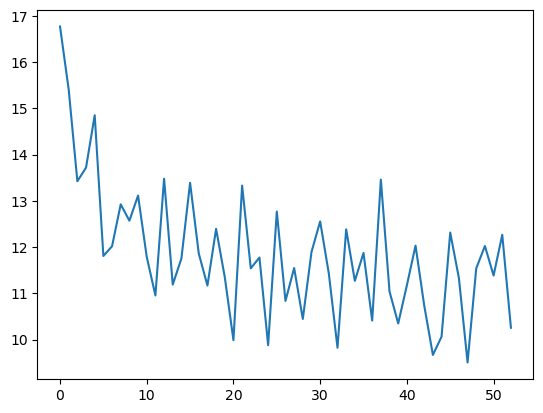

In [6]:
plt.plot(model.loss_curve_)

Run a grid search, including balancing

In [18]:
grid_search = train_mlp_grid_search("MHD", param_grid=None)

Training MLP model for site: MHD with grid search...
Fitting 1 folds for each of 12 candidates, totalling 12 fits
[CV] END activation=relu, alpha=0.0001, batch_size=100, early_stopping=False, hidden_layer_sizes=50, learning_rate=adaptive, max_iter=2000, shuffle=False, solver=adam; total time=   4.0s
[CV] END activation=relu, alpha=0.0001, batch_size=100, early_stopping=False, hidden_layer_sizes=50, learning_rate=constant, max_iter=2000, shuffle=False, solver=adam; total time=   4.2s
[CV] END activation=relu, alpha=0.0001, batch_size=100, early_stopping=False, hidden_layer_sizes=50, learning_rate=constant, max_iter=1000, shuffle=False, solver=adam; total time=   4.2s
[CV] END activation=relu, alpha=0.0001, batch_size=100, early_stopping=False, hidden_layer_sizes=50, learning_rate=adaptive, max_iter=1000, shuffle=False, solver=adam; total time=   4.4s
[CV] END activation=relu, alpha=0.0001, batch_size=100, early_stopping=False, hidden_layer_sizes=(50, 50), learning_rate=constant, max_ite